## 2.1 数据源学习

In [124]:
# import akshare as ak

# df = ak.stock_zh_a_hist(
#     symbol="300750",
#     period="daily",
#     start_date="20260101",
#     end_date="20260618",
#     adjust="qfq"
# )

# df.head()

用stock_zh_a_hist接口函数遇到问题，怀疑网络代理问题/请求敏感/接口不稳定
运行时出现RemoteDisconnected

In [125]:
import os

for key in ["HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "http_proxy", "https_proxy", "all_proxy"]:
    print(key, "=", os.environ.get(key))

HTTP_PROXY = None
HTTPS_PROXY = None
ALL_PROXY = None
http_proxy = None
https_proxy = None
all_proxy = None


检查发现代理没问题，更换热点/Wi-Fi仍然失败 因此采用stock_zh_a_daily

In [126]:
df = ak.stock_zh_a_daily(
    symbol="sz300750",
    start_date="20260101",
    end_date="20260618",
    adjust="qfq"
)
print(df.head())   #打印df的前五行数据
print(df.tail())  #后五行
print(df.shape)   #看这个表有多少行多少列
print(df.columns) #看这个表的列名

         date    open    high     low   close      volume        amount  \
0  2026-01-05  364.29  372.17  362.51  371.68  33688135.0  1.258342e+10   
1  2026-01-06  374.14  374.63  363.35  368.22  34147710.0  1.276480e+10   
2  2026-01-07  367.20  369.69  362.80  365.29  26228535.0  9.730944e+09   
3  2026-01-08  362.32  367.57  361.34  363.51  26959035.0  9.962397e+09   
4  2026-01-09  363.47  371.80  361.35  363.53  31477187.0  1.168104e+10   

   outstanding_share  turnover  
0       4.256573e+09  0.007914  
1       4.256573e+09  0.008022  
2       4.256573e+09  0.006162  
3       4.256573e+09  0.006334  
4       4.256573e+09  0.007395  
           date    open    high     low   close      volume        amount  \
104  2026-06-12  389.99  399.54  383.30  394.85  41420838.0  1.627900e+10   
105  2026-06-15  402.00  407.90  393.41  398.10  34074882.0  1.361356e+10   
106  2026-06-16  408.88  409.02  398.50  403.53  34839262.0  1.410781e+10   
107  2026-06-17  400.00  403.30  395.58  39

注意这个接口中的股票代码前面要加上交易所

拉出来的列：
日期；开盘价；收盘价；最高价；最低价；成交量；成交额；换手率

In [127]:
#检查数据质量
from IPython.display import display

df.info()

display(df.isna().sum())

display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               109 non-null    object 
 1   open               109 non-null    float64
 2   high               109 non-null    float64
 3   low                109 non-null    float64
 4   close              109 non-null    float64
 5   volume             109 non-null    float64
 6   amount             109 non-null    float64
 7   outstanding_share  109 non-null    float64
 8   turnover           109 non-null    float64
dtypes: float64(8), object(1)
memory usage: 7.8+ KB


date                 0
open                 0
high                 0
low                  0
close                0
volume               0
amount               0
outstanding_share    0
turnover             0
dtype: int64

,open,high,low,close,volume,amount,outstanding_share,turnover
count,109.000000,109.000000,109.000000,109.000000,1.090000e+02,1.090000e+02,1.090000e+02,109.000000
mean,391.228440,396.858807,383.715596,389.338899,3.462048e+07,1.370232e+10,4.258266e+09,0.008130
std,35.559488,36.137088,33.822207,34.744616,9.245673e+06,4.150578e+09,1.670784e+06,0.002171
min,332.670000,336.740000,327.870000,333.670000,1.725762e+07,6.675633e+09,4.256573e+09,0.004051
25%,360.130000,362.320000,352.490000,357.340000,2.775458e+07,1.074569e+10,4.256629e+09,0.006520
50%,395.570000,402.680000,387.720000,394.320000,3.386717e+07,1.350230e+10,4.256828e+09,0.007956
75%,419.870000,426.640000,411.290000,417.230000,3.879816e+07,1.612238e+10,4.259932e+09,0.009107
max,468.750000,468.750000,448.630000,460.000000,6.350622e+07,2.851742e+10,4.260050e+09,0.014908


In [128]:
financial_df = ak.stock_financial_abstract(symbol="300750")

from IPython.display import display

display(financial_df.head())
display(financial_df.shape)
display(financial_df.columns)

,选项,指标,20260331,20251231,20250930,20250630,20250331,20241231,20240930,20240630,...,20180930,20180630,20180331,20171231,20170930,20170630,20170331,20161231,20151231,20141231
0,常用指标,归母净利润,2.073771e+10,7.220128e+10,4.903411e+10,3.048514e+10,1.396256e+10,5.074468e+10,3.600107e+10,2.286499e+10,...,2.378500e+09,9.109543e+08,4.133472e+08,3.877955e+09,2.570510e+09,1.811112e+09,-1.168792e+07,2.851821e+09,9.306464e+08,5.442575e+07
1,常用指标,营业总收入,1.291310e+11,4.237018e+11,2.830720e+11,1.788863e+11,8.470459e+10,3.620126e+11,2.590447e+11,1.667668e+11,...,1.913592e+10,9.359581e+09,3.711641e+09,1.999686e+10,1.197090e+10,6.294695e+09,1.454386e+09,1.487899e+10,5.702885e+09,8.667864e+08
2,常用指标,营业成本,1.071044e+11,3.448242e+11,2.319625e+11,1.463912e+11,7.059155e+10,3.033039e+11,2.154715e+11,1.422968e+11,...,1.607977e+10,8.213087e+09,3.353698e+09,1.687526e+10,1.040280e+10,5.530002e+09,1.551974e+09,1.158474e+10,4.658156e+09,8.665207e+08
3,常用指标,净利润,2.273725e+10,7.678631e+10,5.229687e+10,3.236545e+10,1.486163e+10,5.400679e+10,3.873326e+10,2.487886e+10,...,2.642236e+09,1.069894e+09,4.692645e+08,4.194057e+09,2.831288e+09,1.974921e+09,1.649520e+07,2.918437e+09,9.505811e+08,5.556379e+07
4,常用指标,扣非净利润,1.809264e+10,6.450786e+10,4.361922e+10,2.719747e+10,1.182917e+10,4.499292e+10,3.217641e+10,2.005394e+10,...,1.985087e+09,6.972436e+08,2.690698e+08,2.375678e+09,NaN,5.564430e+08,-1.293230e+08,2.786451e+09,8.800957e+08,1.309770e+07


(80, 42)

Index(['选项', '指标', '20260331', '20251231', '20250930', '20250630', '20250331',
       '20241231', '20240930', '20240630', '20240331', '20231231', '20230930',
       '20230630', '20230331', '20221231', '20220930', '20220630', '20220331',
       '20211231', '20210930', '20210630', '20210331', '20201231', '20200930',
       '20200630', '20200331', '20191231', '20190930', '20190630', '20190331',
       '20181231', '20180930', '20180630', '20180331', '20171231', '20170930',
       '20170630', '20170331', '20161231', '20151231', '20141231'],
      dtype='object')

ak.stock_financial_abstract 拉取了宁德时代的财务摘要数据

In [129]:
# fund_flow_df = ak.stock_individual_fund_flow(stock="300750", market="sz")
# fund_flow_df.head()

尝试使用 stock_individual_fund_flow 获取个股资金流向数据时，出现 RemoteDisconnected
这个错误和前面 stock_zh_a_hist 类似

In [130]:
# lhb_df = ak.stock_sina_lhb_detail_daily(
#     trade_date="20260618"
# )

# lhb_df.head()

当前安装的AkShare版本中 没有此函数，因此我检查一下库中有哪些函数与龙虎榜有关

In [131]:
[x for x in dir(ak) if "lhb" in x.lower()]

['option_lhb_em',
 'stock_lhb_detail_daily_sina',
 'stock_lhb_detail_em',
 'stock_lhb_ggtj_sina',
 'stock_lhb_hyyyb_em',
 'stock_lhb_jgmmtj_em',
 'stock_lhb_jgmx_sina',
 'stock_lhb_jgstatistic_em',
 'stock_lhb_jgzz_sina',
 'stock_lhb_stock_detail_date_em',
 'stock_lhb_stock_detail_em',
 'stock_lhb_stock_statistic_em',
 'stock_lhb_traderstatistic_em',
 'stock_lhb_yyb_detail_em',
 'stock_lhb_yybph_em',
 'stock_lhb_yytj_sina']

可见任务文件中的函数名已经过时 应该用'stock_lhb_detail_daily_sina'

In [132]:
lhb_df = ak.stock_lhb_detail_daily_sina(
    date="20250618"
)

lhb_df.head()

,序号,股票代码,股票名称,收盘价,对应值,成交量,成交额,指标
0,1,000020,深华发A,15.16,21.08,3627.8350,51653.7225,连续三个交易日内，涨幅偏离值累计达20%的证券
1,2,002015,协鑫能科,12.96,21.10,10679.7292,135914.3767,连续三个交易日内，涨幅偏离值累计达20%的证券
2,3,002207,*ST准油,9.14,21.15,7981.5297,66642.8816,连续三个交易日内，涨幅偏离值累计达20%的证券
3,4,002490,山东墨龙,5.80,21.18,27171.2414,146968.8025,连续三个交易日内，涨幅偏离值累计达20%的证券
4,5,002537,海联金汇,9.45,20.96,80869.2984,723074.3548,连续三个交易日内，涨幅偏离值累计达20%的证券


2.1小结：
除了资金流向接口不稳定外，其他数据源均成功获取
## 2.2 Python数据处理实操

- 先不直接拉沪深300全部成分股，因为数量太多，而且接口有时不稳定
- 先用 watchlist 里的几只股票试试

In [133]:
import pandas as pd
from IPython.display import display

stock_list = [
    {"code": "sh600519", "name": "贵州茅台"},
    {"code": "sz300750", "name": "宁德时代"},
    {"code": "sz002594", "name": "比亚迪"},
    {"code": "sh600036", "name": "招商银行"},
    {"code": "sh600900", "name": "长江电力"},
]
start_date = "20250617"
end_date = "20260617"


第一步：批量获取日线数据。这里继续使用前面能跑通的 stock_zh_a_daily，并且设置 adjust="qfq"


In [134]:
all_daily_data = {}

for stock in stock_list:
    code = stock["code"]
    name = stock["name"]
    print(f"正在获取：{name} {code}")
    
    try:
        temp_df = ak.stock_zh_a_daily(
            symbol=code,
            start_date=start_date,
            end_date=end_date,
            adjust="qfq"
        )
        
        temp_df = temp_df.copy()
        temp_df["stock_code"] = code
        temp_df["stock_name"] = name
        all_daily_data[code] = temp_df
        
        print(f"成功：{name}，数据行数：{len(temp_df)}")
    except Exception as e:
        print(f"失败：{name}，原因：{e}")

print("完成。成功获取的股票数量：", len(all_daily_data))


正在获取：贵州茅台 sh600519
成功：贵州茅台，数据行数：244
正在获取：宁德时代 sz300750
成功：宁德时代，数据行数：244
正在获取：比亚迪 sz002594
成功：比亚迪，数据行数：244
正在获取：招商银行 sh600036
成功：招商银行，数据行数：244
正在获取：长江电力 sh600900
成功：长江电力，数据行数：244
完成。成功获取的股票数量： 5


第二步：把多只股票的数据合并成一张总表


In [135]:
daily_df = pd.concat(all_daily_data.values(), ignore_index=True)

display(daily_df.head())
display(daily_df.tail())
display(daily_df.shape)
display(daily_df.columns)


,date,open,high,low,close,volume,amount,outstanding_share,turnover,stock_code,stock_name
0,2025-06-17,1369.39,1376.14,1361.85,1376.14,2723151.0,3.868365e+09,1.256198e+09,0.002168,sh600519,贵州茅台
1,2025-06-18,1388.68,1391.99,1370.36,1374.21,3076099.0,4.404131e+09,1.256198e+09,0.002449,sh600519,贵州茅台
2,2025-06-19,1375.18,1382.57,1366.67,1375.18,2450072.0,3.490269e+09,1.256198e+09,0.001950,sh600519,贵州茅台
3,2025-06-20,1372.84,1389.78,1369.58,1377.74,3481581.0,4.990683e+09,1.256198e+09,0.002772,sh600519,贵州茅台
4,2025-06-23,1369.39,1381.93,1355.10,1369.39,2672331.0,3.794012e+09,1.256198e+09,0.002127,sh600519,贵州茅台


,date,open,high,low,close,volume,amount,outstanding_share,turnover,stock_code,stock_name
1215,2026-06-11,27.69,27.95,27.60,27.89,99125010.0,2.759359e+09,2.446822e+10,0.004051,sh600900,长江电力
1216,2026-06-12,27.77,28.29,27.67,28.28,149424523.0,4.191924e+09,2.446822e+10,0.006107,sh600900,长江电力
1217,2026-06-15,28.24,28.24,27.39,27.57,207661158.0,5.743668e+09,2.446822e+10,0.008487,sh600900,长江电力
1218,2026-06-16,27.41,27.45,27.14,27.19,120599299.0,3.287064e+09,2.446822e+10,0.004929,sh600900,长江电力
1219,2026-06-17,27.22,27.27,26.91,27.00,103444150.0,2.794894e+09,2.446822e+10,0.004228,sh600900,长江电力


(1220, 11)

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'amount',
       'outstanding_share', 'turnover', 'stock_code', 'stock_name'],
      dtype='object')

第三步：检查缺失值


In [136]:
missing_report = pd.DataFrame({
    "missing_count": daily_df.isna().sum(),
    "missing_ratio": daily_df.isna().mean()
})

display(missing_report)


,missing_count,missing_ratio
date,0,0.0
open,0,0.0
high,0,0.0
low,0,0.0
close,0,0.0
volume,0,0.0
amount,0,0.0
outstanding_share,0,0.0
turnover,0,0.0
stock_code,0,0.0


- 如果价格、成交量这类关键字段有空值，后面算均线或画图可能会受影响
- 这块假设有的话 做删除处理

In [137]:
key_columns = ["open", "high", "low", "close", "volume"]

before_rows = len(daily_df)
daily_df = daily_df.dropna(subset=key_columns).copy()
after_rows = len(daily_df)

print("删除前行数：", before_rows)
print("删除后行数：", after_rows)
print("删除行数：", before_rows - after_rows)


删除前行数： 1220
删除后行数： 1220
删除行数： 0


第四步：异常值 Winsorize 缩尾。
- 先对 volume 和 amount 做 1% / 99% 分位数缩尾。意思是：太小的值压到 1% 分位数，太大的值压到 99% 分位数，避免极端值影响后面分析

In [138]:
def winsorize_by_group(df, group_col, value_col, lower_q=0.01, upper_q=0.99):
    result = df.copy()
    new_col = value_col + "_winsor"
    
    def clip_one_group(s):
        lower = s.quantile(lower_q)
        upper = s.quantile(upper_q)
        return s.clip(lower=lower, upper=upper)
    
    result[new_col] = result.groupby(group_col)[value_col].transform(clip_one_group)
    return result

for col in ["volume", "amount"]:
    if col in daily_df.columns:
        daily_df = winsorize_by_group(daily_df, "stock_code", col)

display(daily_df.head())


,date,open,high,low,close,volume,amount,outstanding_share,turnover,stock_code,stock_name,volume_winsor,amount_winsor
0,2025-06-17,1369.39,1376.14,1361.85,1376.14,2723151.0,3.868365e+09,1.256198e+09,0.002168,sh600519,贵州茅台,2723151.0,3.868365e+09
1,2025-06-18,1388.68,1391.99,1370.36,1374.21,3076099.0,4.404131e+09,1.256198e+09,0.002449,sh600519,贵州茅台,3076099.0,4.404131e+09
2,2025-06-19,1375.18,1382.57,1366.67,1375.18,2450072.0,3.490269e+09,1.256198e+09,0.001950,sh600519,贵州茅台,2450072.0,3.490269e+09
3,2025-06-20,1372.84,1389.78,1369.58,1377.74,3481581.0,4.990683e+09,1.256198e+09,0.002772,sh600519,贵州茅台,3481581.0,4.990683e+09
4,2025-06-23,1369.39,1381.93,1355.10,1369.39,2672331.0,3.794012e+09,1.256198e+09,0.002127,sh600519,贵州茅台,2672331.0,3.794012e+09


第五步：计算基础技术指标。这里先算 5日均线、20日均线、日收益率、5日成交量均线。它们都是后面画图和做简单趋势观察会用到的字段。


In [139]:
daily_df = daily_df.sort_values(["stock_code", "date"]).copy()

daily_df["ma5"] = daily_df.groupby("stock_code")["close"].transform(lambda s: s.rolling(5).mean())
daily_df["ma20"] = daily_df.groupby("stock_code")["close"].transform(lambda s: s.rolling(20).mean())
daily_df["daily_return"] = daily_df.groupby("stock_code")["close"].pct_change()
daily_df["volume_ma5"] = daily_df.groupby("stock_code")["volume"].transform(lambda s: s.rolling(5).mean())

display(daily_df[["date", "stock_code", "stock_name", "close", "ma5", "ma20", "daily_return", "volume", "volume_ma5"]].head(25))


,date,stock_code,stock_name,close,ma5,ma20,daily_return,volume,volume_ma5
732,2025-06-17,sh600036,招商银行,42.96,NaN,NaN,NaN,47420901.0,NaN
733,2025-06-18,sh600036,招商银行,42.84,NaN,NaN,-0.002793,42642859.0,NaN
734,2025-06-19,sh600036,招商银行,42.63,NaN,NaN,-0.004902,51345430.0,NaN
735,2025-06-20,sh600036,招商银行,42.97,NaN,NaN,0.007976,44815652.0,NaN
736,2025-06-23,sh600036,招商银行,43.21,42.922,NaN,0.005585,53893148.0,48023598.0
737,2025-06-24,sh600036,招商银行,43.68,43.066,NaN,0.010877,65581461.0,51655710.0
738,2025-06-25,sh600036,招商银行,44.38,43.374,NaN,0.016026,60767987.0,55280735.6
739,2025-06-26,sh600036,招商银行,44.74,43.796,NaN,0.008112,59020064.0,56815662.4
740,2025-06-27,sh600036,招商银行,43.18,43.838,NaN,-0.034868,95414320.0,66935396.0
741,2025-06-30,sh600036,招商银行,42.93,43.782,NaN,-0.005790,62461363.0,68649039.0


这里要注意：`ma5` 前 4 行为空、`ma20` 前 19 行为空是正常的。因为计算 5日均线至少需要前 5 天数据，计算 20日均线至少需要前 20 天数据。


In [140]:
indicator_missing = daily_df[["ma5", "ma20", "daily_return", "volume_ma5"]].isna().sum()
display(indicator_missing)


ma5             20
ma20            95
daily_return     5
volume_ma5      20
dtype: int64

5只股票的试验完成，保存一下这个表

In [141]:
from pathlib import Path

output_dir = Path("data")
output_dir.mkdir(exist_ok=True)

daily_df.to_csv(output_dir / "week2_daily_processed.csv", index=False, encoding="utf-8-sig")

来做可视化（先拿宁德时代）

In [142]:
# import matplotlib.pyplot as plt

# one_stock = daily_df[daily_df["stock_code"] == "sz300750"].copy()

# plt.figure(figsize=(12, 5))
# plt.plot(one_stock["date"], one_stock["close"], label="close")
# plt.plot(one_stock["date"], one_stock["ma5"], label="MA5")
# plt.plot(one_stock["date"], one_stock["ma20"], label="MA20")

# plt.title("宁德时代 收盘价与均线")
# plt.xlabel("date")
# plt.ylabel("price")
# plt.legend()
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

画了这些：
- 宁德时代的收盘价走势
- 5日均线
- 20日均线

但是标题乱码（matplotbil默认字体不支持中文）那就先用英文

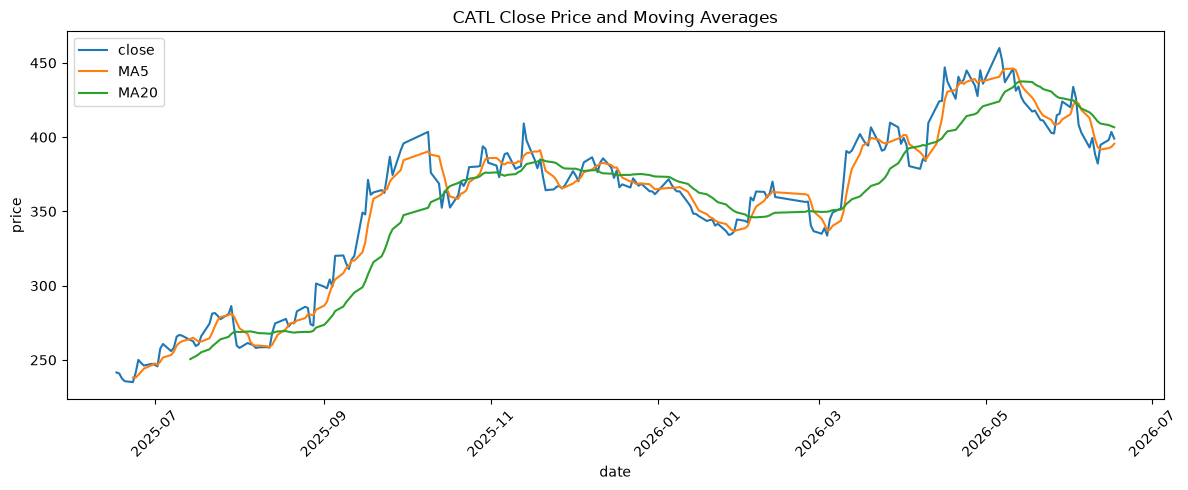

In [143]:
import matplotlib.pyplot as plt

one_stock = daily_df[daily_df["stock_code"] == "sz300750"].copy()

plt.figure(figsize=(12, 5))
plt.plot(one_stock["date"], one_stock["close"], label="close")
plt.plot(one_stock["date"], one_stock["ma5"], label="MA5")
plt.plot(one_stock["date"], one_stock["ma20"], label="MA20")

plt.title("CATL Close Price and Moving Averages")
plt.xlabel("date")
plt.ylabel("price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

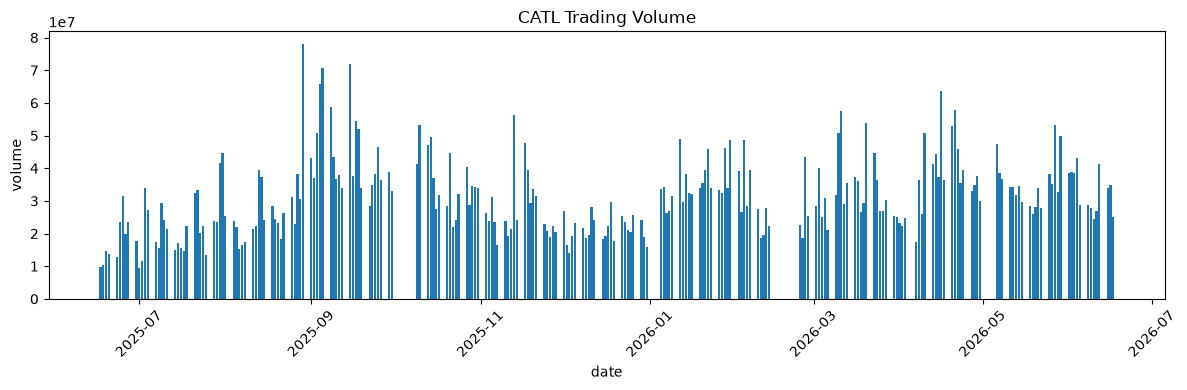

In [144]:
plt.figure(figsize=(12, 4))
plt.bar(one_stock["date"], one_stock["volume"])

plt.title("CATL Trading Volume")
plt.xlabel("date")
plt.ylabel("volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

这是成交量图，检查无问题之后封装价格图和成交量在一个函数中

In [145]:
def plot_stock_price_volume(daily_df, stock_code, stock_name):
    one_stock = daily_df[daily_df["stock_code"] == stock_code].copy()
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    axes[0].plot(one_stock["date"], one_stock["close"], label="close")
    axes[0].plot(one_stock["date"], one_stock["ma5"], label="MA5")
    axes[0].plot(one_stock["date"], one_stock["ma20"], label="MA20")
    axes[0].set_title(f"{stock_name} Close Price and Moving Averages")
    axes[0].set_ylabel("price")
    axes[0].legend()
    
    axes[1].bar(one_stock["date"], one_stock["volume"])
    axes[1].set_title(f"{stock_name} Trading Volume")
    axes[1].set_xlabel("date")
    axes[1].set_ylabel("volume")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

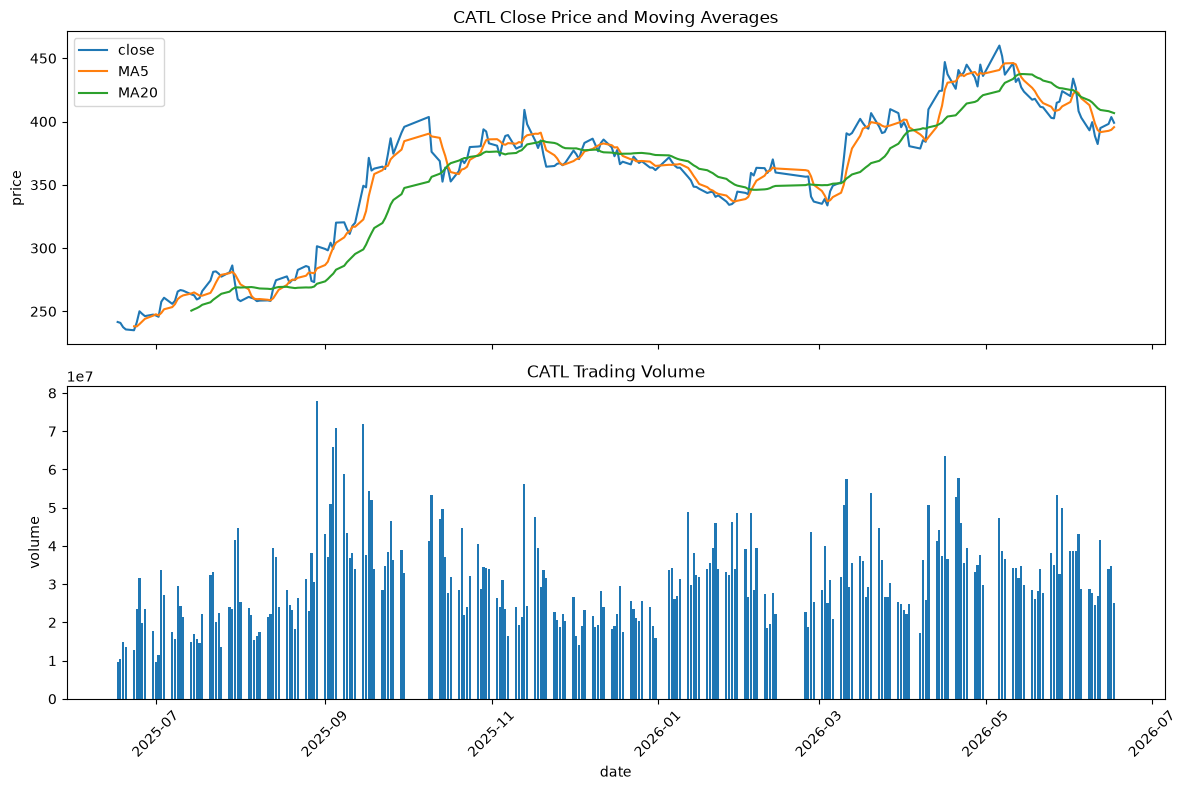

In [146]:
plot_stock_price_volume(daily_df, "sz300750", "CATL")

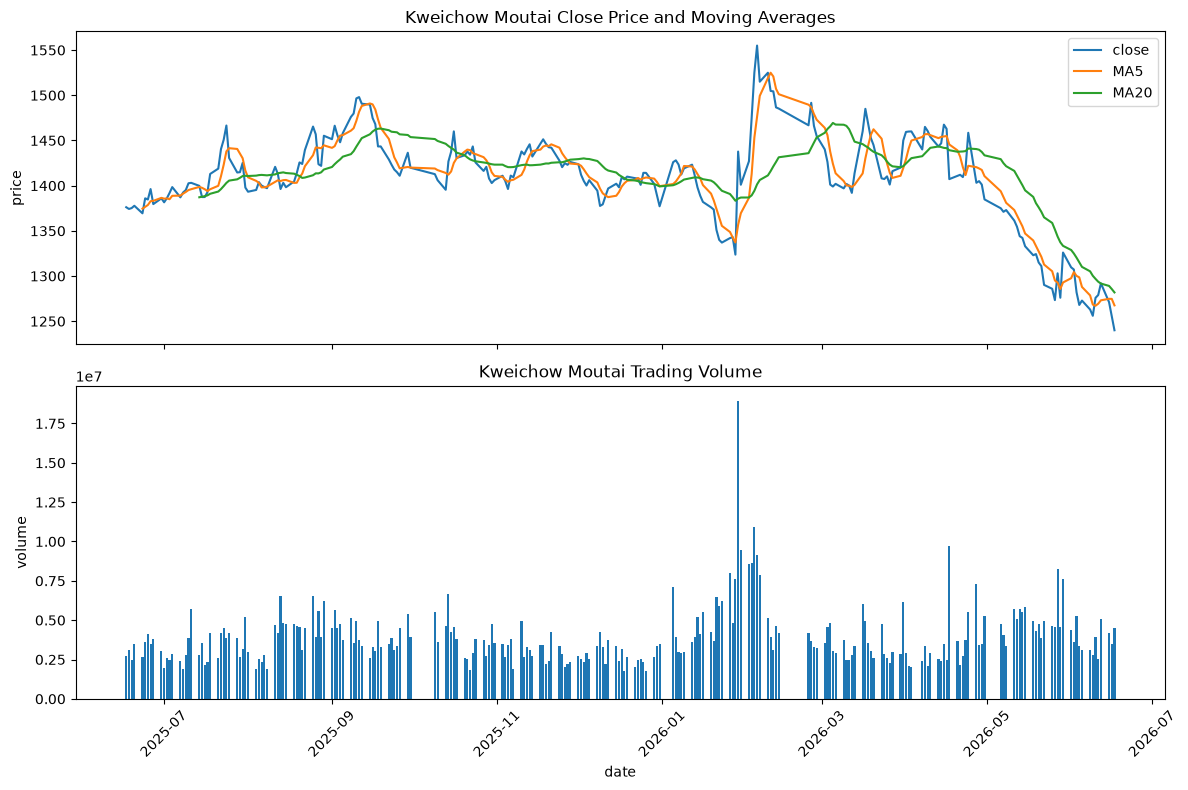

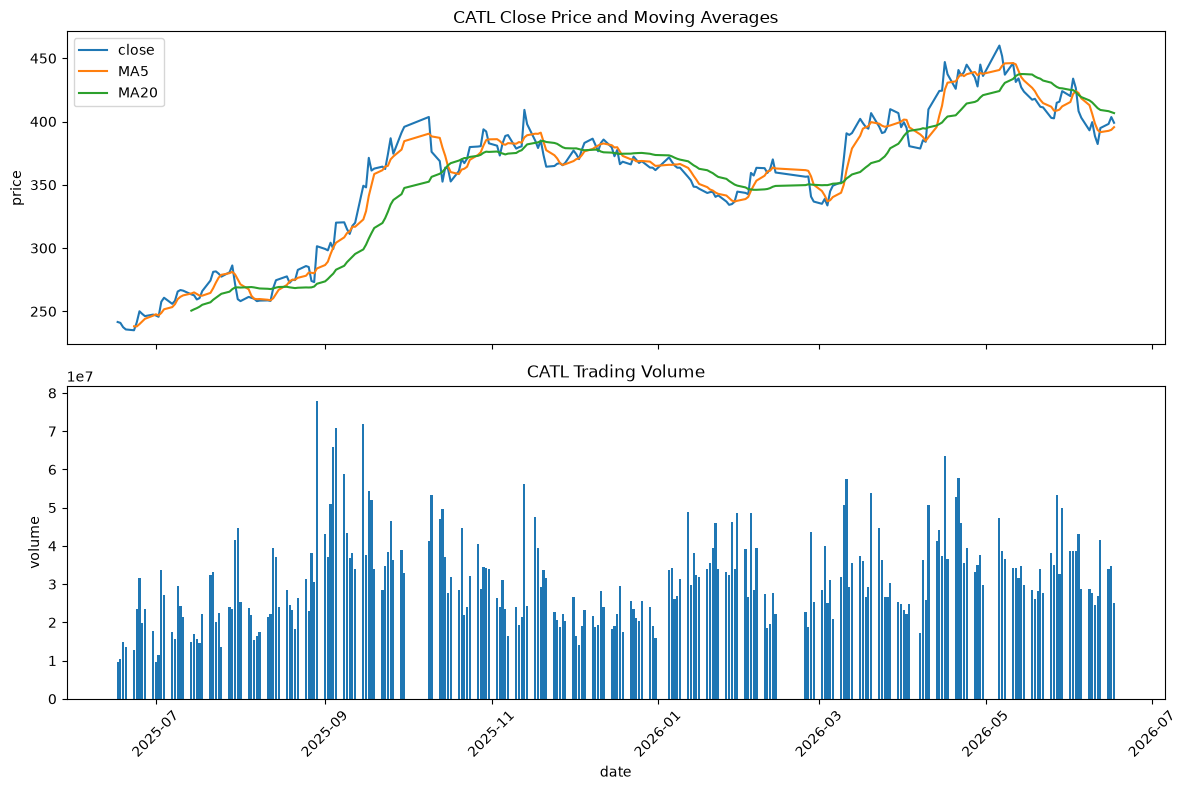

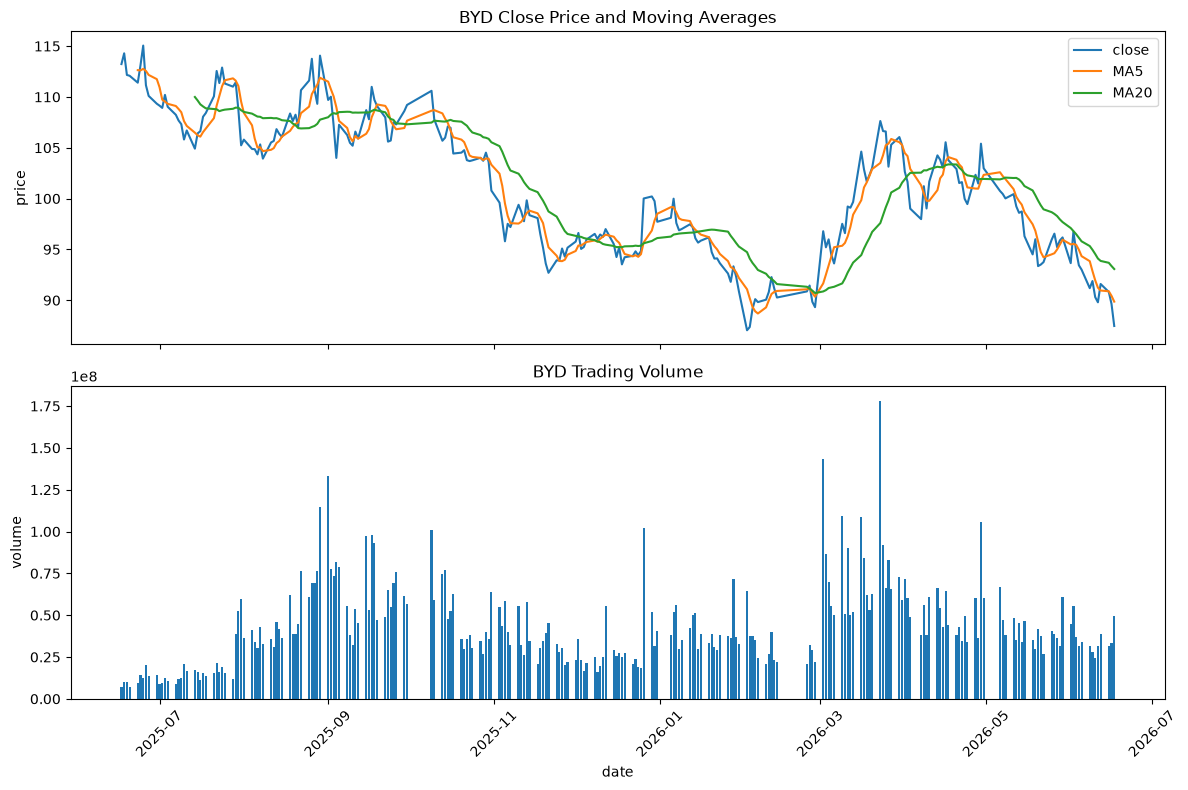

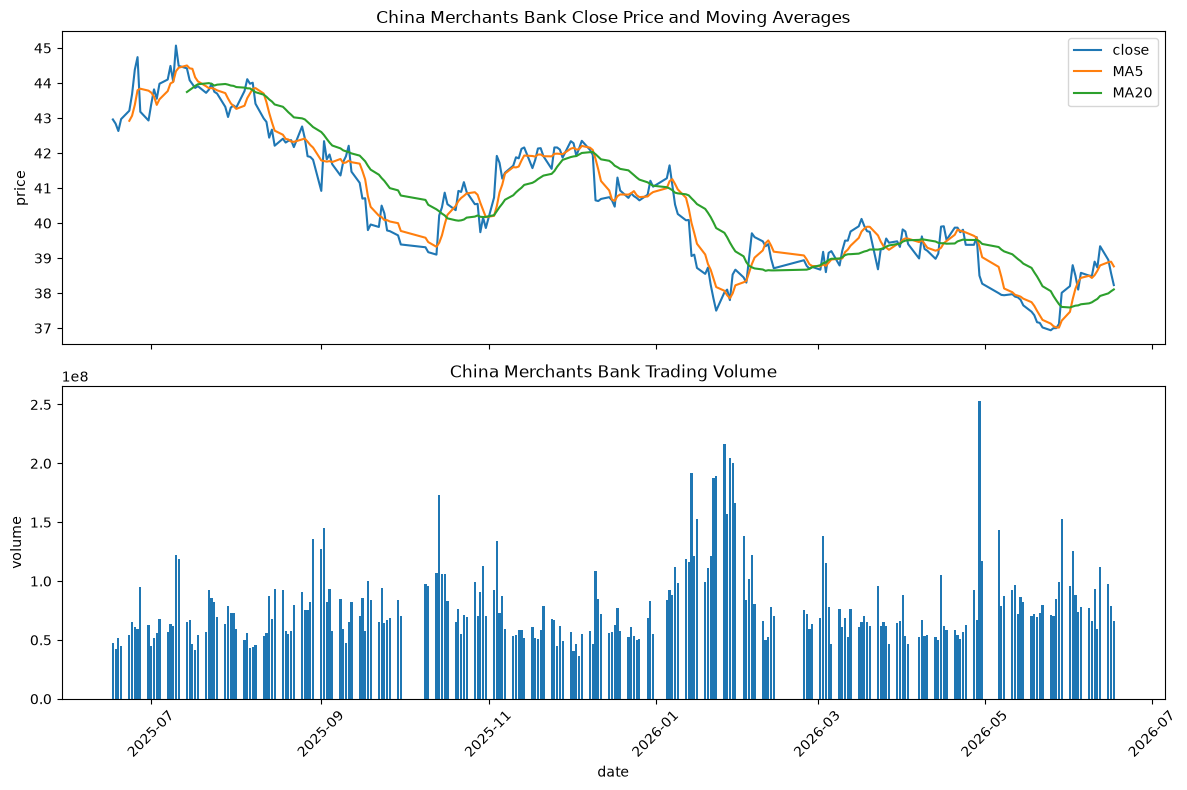

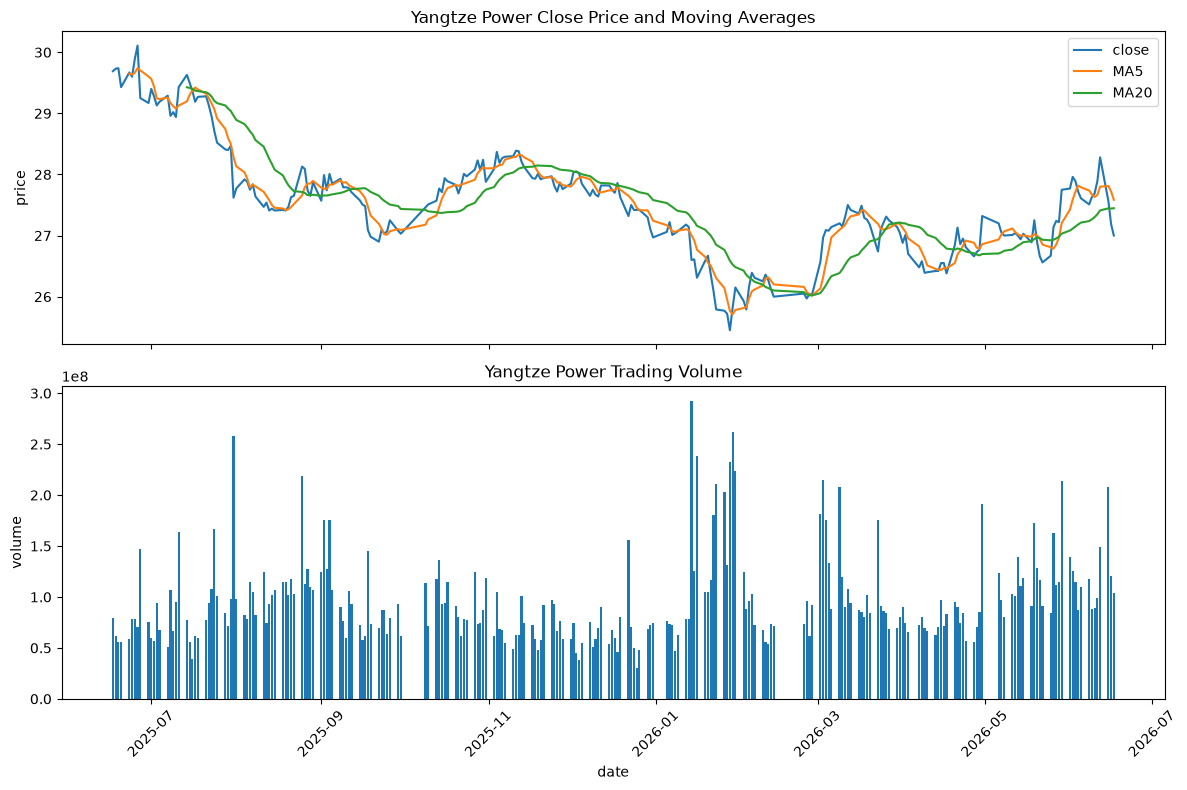

In [147]:
name_map = {
    "sh600519": "Kweichow Moutai",
    "sz300750": "CATL",
    "sz002594": "BYD",
    "sh600036": "China Merchants Bank",
    "sh600900": "Yangtze Power",
}

for code, name in name_map.items():
    plot_stock_price_volume(daily_df, code, name)

检查没问题之后改写函数 自动保存到此目录下面的data/charts中

In [148]:
from pathlib import Path

chart_dir = Path("data/charts")
chart_dir.mkdir(parents=True, exist_ok=True)

In [149]:
def plot_stock_price_volume(daily_df, stock_code, stock_name, save=True):
    one_stock = daily_df[daily_df["stock_code"] == stock_code].copy()
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    axes[0].plot(one_stock["date"], one_stock["close"], label="close")
    axes[0].plot(one_stock["date"], one_stock["ma5"], label="MA5")
    axes[0].plot(one_stock["date"], one_stock["ma20"], label="MA20")
    axes[0].set_title(f"{stock_name} Close Price and Moving Averages")
    axes[0].set_ylabel("price")
    axes[0].legend()
    
    axes[1].bar(one_stock["date"], one_stock["volume"])
    axes[1].set_title(f"{stock_name} Trading Volume")
    axes[1].set_xlabel("date")
    axes[1].set_ylabel("volume")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    if save:
        file_path = chart_dir / f"{stock_code}_{stock_name}_price_volume.png"
        plt.savefig(file_path, dpi=150, bbox_inches="tight")
        print("已保存：", file_path)
    
    plt.show()

已保存： data/charts/sh600519_Kweichow_Moutai_price_volume.png


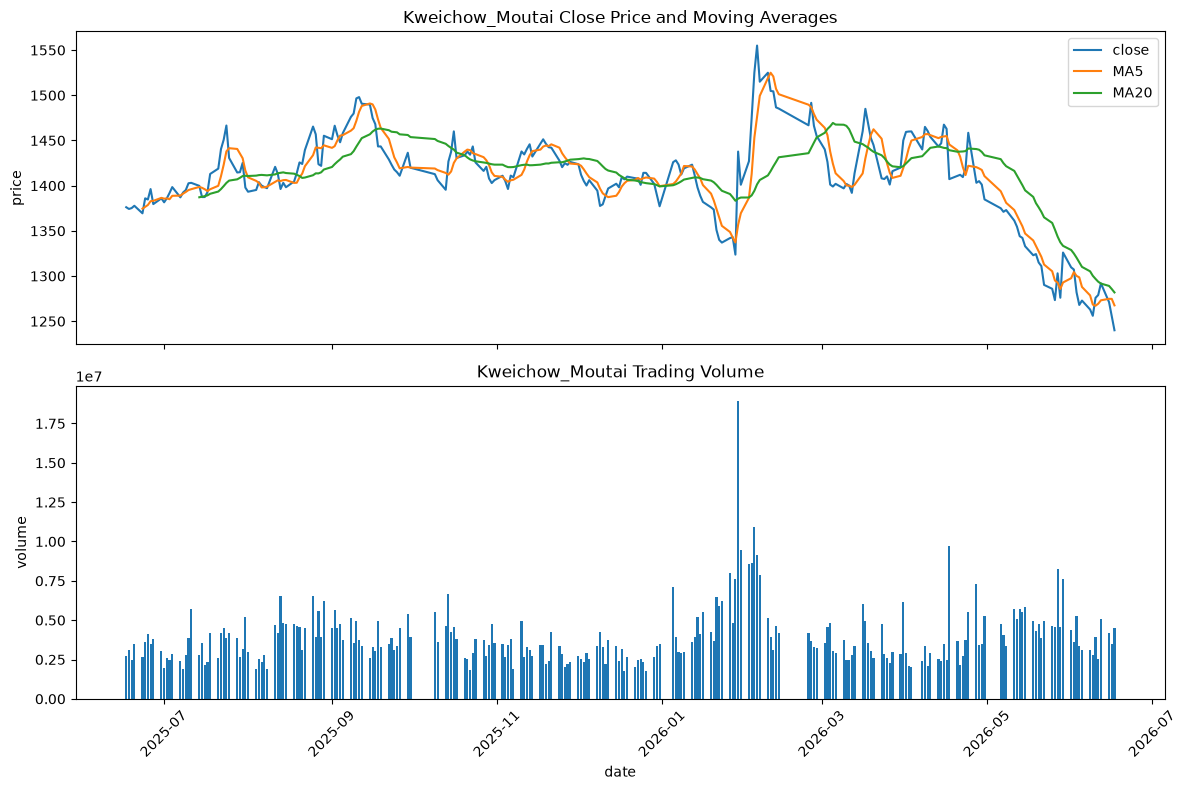

已保存： data/charts/sz300750_CATL_price_volume.png


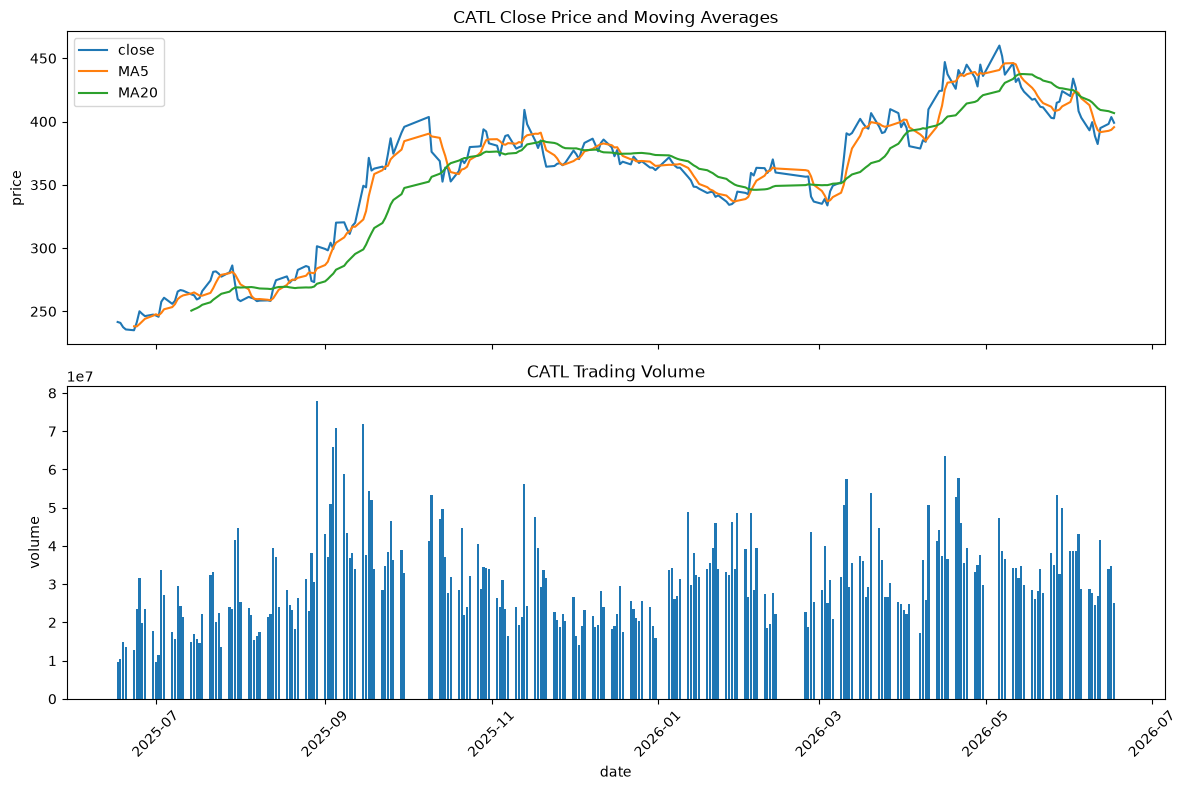

已保存： data/charts/sz002594_BYD_price_volume.png


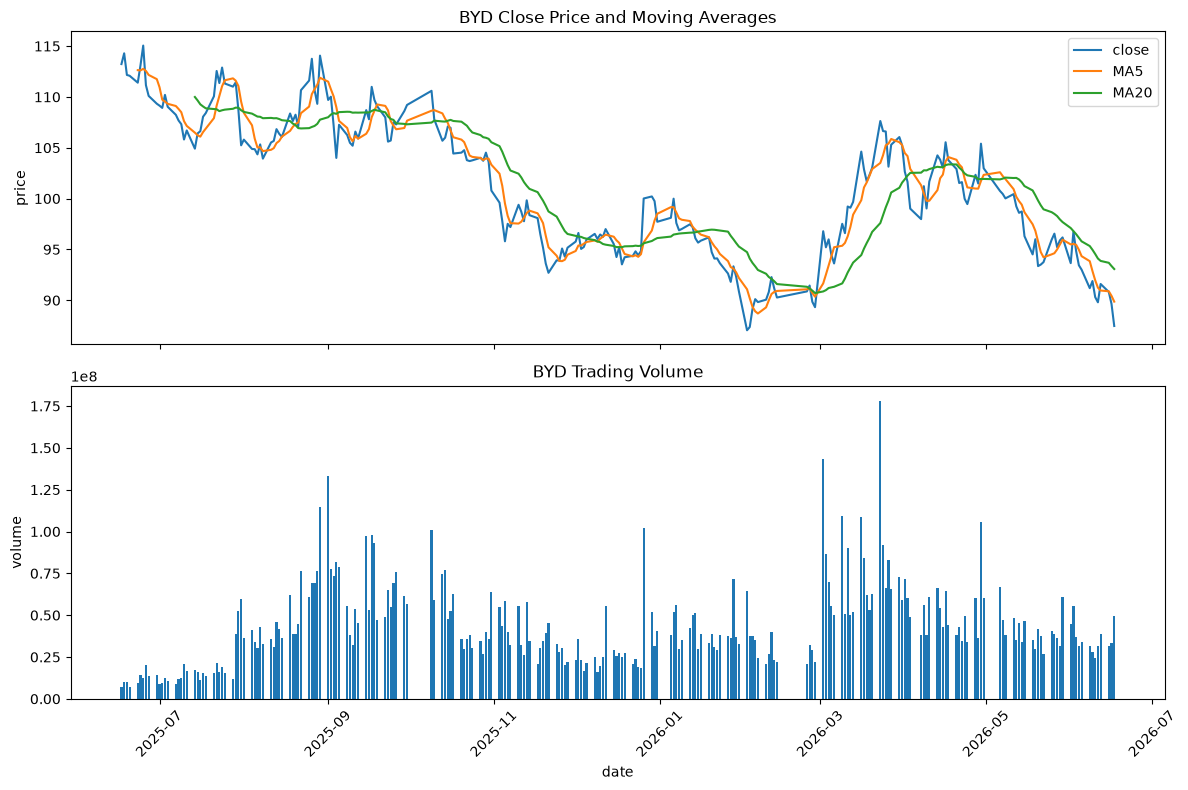

已保存： data/charts/sh600036_China_Merchants_Bank_price_volume.png


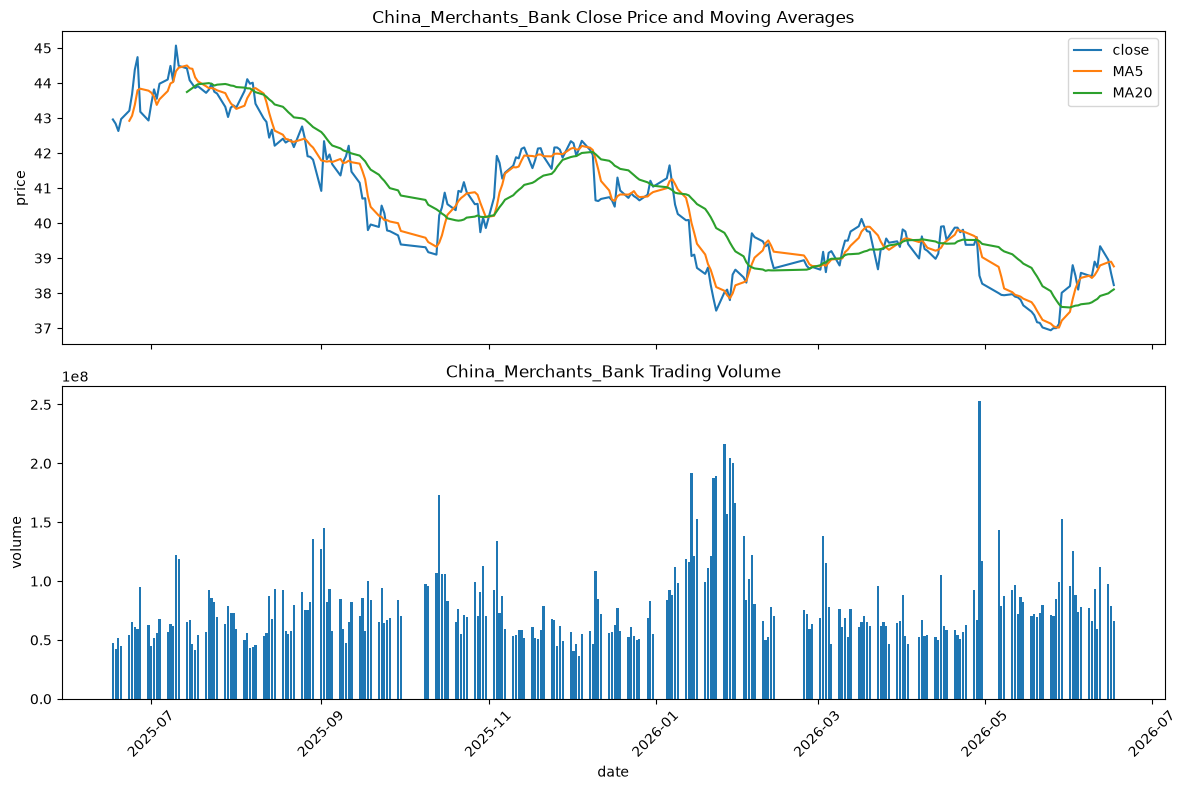

已保存： data/charts/sh600900_Yangtze_Power_price_volume.png


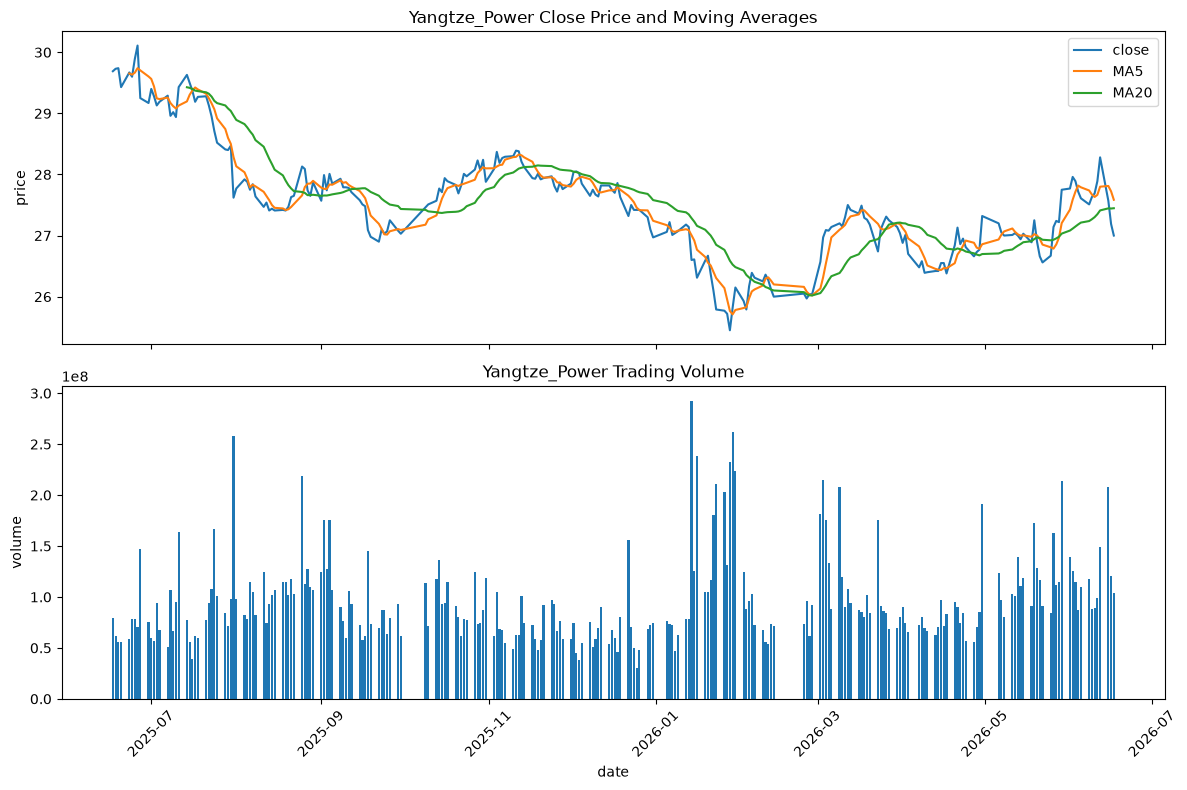

In [150]:
name_map = {
    "sh600519": "Kweichow_Moutai",
    "sz300750": "CATL",
    "sz002594": "BYD",
    "sh600036": "China_Merchants_Bank",
    "sh600900": "Yangtze_Power",
}

for code, name in name_map.items():
    plot_stock_price_volume(daily_df, code, name, save=True)


以下是沪深300成分股的代码

In [151]:
hs300_df = ak.index_stock_cons_csindex(symbol="000300")

display(hs300_df.head())
display(hs300_df.shape)
display(hs300_df.columns)

,日期,指数代码,指数名称,指数英文名称,成分券代码,成分券名称,成分券英文名称,交易所,交易所英文名称
0,2026-06-18,000300,沪深300,CSI 300,000001,平安银行,"Ping An Bank Co., Ltd.",深圳证券交易所,Shenzhen Stock Exchange
1,2026-06-18,000300,沪深300,CSI 300,000002,万科A,China Vanke Co Ltd,深圳证券交易所,Shenzhen Stock Exchange
2,2026-06-18,000300,沪深300,CSI 300,000063,中兴通讯,ZTE Corporation,深圳证券交易所,Shenzhen Stock Exchange
3,2026-06-18,000300,沪深300,CSI 300,000100,TCL科技,TCL Technology Group Corporation,深圳证券交易所,Shenzhen Stock Exchange
4,2026-06-18,000300,沪深300,CSI 300,000157,中联重科,Zoomlion Heavy Industry Science & Technology C...,深圳证券交易所,Shenzhen Stock Exchange


(300, 9)

Index(['日期', '指数代码', '指数名称', '指数英文名称', '成分券代码', '成分券名称', '成分券英文名称', '交易所',
       '交易所英文名称'],
      dtype='object')

由于之前接口问题，这里写一小段成分股代码转换的函数

In [152]:
def add_market_prefix(code):
    code = str(code).zfill(6)
    
    if code.startswith("6"):
        return "sh" + code
    else:
        return "sz" + code

In [153]:
hs300_stock_list = []

for _, row in hs300_df.iterrows():
    raw_code = row["成分券代码"]
    stock_name = row["成分券名称"]
    
    hs300_stock_list.append({
        "code": add_market_prefix(raw_code),
        "name": stock_name
    })

hs300_stock_list[:20]

[{'code': 'sz000001', 'name': '平安银行'},
 {'code': 'sz000002', 'name': '万科A'},
 {'code': 'sz000063', 'name': '中兴通讯'},
 {'code': 'sz000100', 'name': 'TCL科技'},
 {'code': 'sz000157', 'name': '中联重科'},
 {'code': 'sz000166', 'name': '申万宏源'},
 {'code': 'sz000301', 'name': '东方盛虹'},
 {'code': 'sz000333', 'name': '美的集团'},
 {'code': 'sz000338', 'name': '潍柴动力'},
 {'code': 'sz000408', 'name': '藏格矿业'},
 {'code': 'sz000425', 'name': '徐工机械'},
 {'code': 'sz000538', 'name': '云南白药'},
 {'code': 'sz000568', 'name': '泸州老窖'},
 {'code': 'sz000596', 'name': '古井贡酒'},
 {'code': 'sz000617', 'name': '中油资本'},
 {'code': 'sz000625', 'name': '长安汽车'},
 {'code': 'sz000630', 'name': '铜陵有色'},
 {'code': 'sz000651', 'name': '格力电器'},
 {'code': 'sz000657', 'name': '中钨高新'},
 {'code': 'sz000708', 'name': '中信特钢'}]

In [154]:
all_daily_data = {}

for stock in hs300_stock_list:
    code = stock["code"]
    name = stock["name"]
    print(f"正在获取：{name} {code}")
    
    try:
        temp_df = ak.stock_zh_a_daily(
            symbol=code,
            start_date=start_date,
            end_date=end_date,
            adjust="qfq"
        )
        
        temp_df = temp_df.copy()
        temp_df["stock_code"] = code
        temp_df["stock_name"] = name
        all_daily_data[code] = temp_df
        
        print(f"成功：{name}，数据行数：{len(temp_df)}")
    except Exception as e:
        print(f"失败：{name}，原因：{e}")

print("完成。成功获取的股票数量：", len(all_daily_data))


正在获取：平安银行 sz000001
成功：平安银行，数据行数：244
正在获取：万科A sz000002
成功：万科A，数据行数：244
正在获取：中兴通讯 sz000063
成功：中兴通讯，数据行数：244
正在获取：TCL科技 sz000100
成功：TCL科技，数据行数：244
正在获取：中联重科 sz000157
成功：中联重科，数据行数：244
正在获取：申万宏源 sz000166
成功：申万宏源，数据行数：244
正在获取：东方盛虹 sz000301
成功：东方盛虹，数据行数：244
正在获取：美的集团 sz000333
成功：美的集团，数据行数：244
正在获取：潍柴动力 sz000338
成功：潍柴动力，数据行数：244
正在获取：藏格矿业 sz000408
成功：藏格矿业，数据行数：244
正在获取：徐工机械 sz000425
成功：徐工机械，数据行数：244
正在获取：云南白药 sz000538
成功：云南白药，数据行数：244
正在获取：泸州老窖 sz000568
成功：泸州老窖，数据行数：244
正在获取：古井贡酒 sz000596
成功：古井贡酒，数据行数：244
正在获取：中油资本 sz000617
成功：中油资本，数据行数：244
正在获取：长安汽车 sz000625
成功：长安汽车，数据行数：244
正在获取：铜陵有色 sz000630
成功：铜陵有色，数据行数：244
正在获取：格力电器 sz000651
成功：格力电器，数据行数：244
正在获取：中钨高新 sz000657
成功：中钨高新，数据行数：244
正在获取：中信特钢 sz000708
成功：中信特钢，数据行数：244
正在获取：京东方A sz000725
成功：京东方A，数据行数：244
正在获取：中航西飞 sz000768
成功：中航西飞，数据行数：244
正在获取：广发证券 sz000776
成功：广发证券，数据行数：244
正在获取：盐湖股份 sz000792
成功：盐湖股份，数据行数：244
正在获取：云铝股份 sz000807
成功：云铝股份，数据行数：244
正在获取：五 粮 液 sz000858
成功：五 粮 液，数据行数：244
正在获取：双汇发展 sz000895
成功：双汇发展，数据行数：244
正在获取：紫光股份 sz000938
成功：紫光股份

In [155]:
#合成总表
daily_df = pd.concat(all_daily_data.values(), ignore_index=True)

#检查缺失
missing_report = pd.DataFrame({
    "missing_count": daily_df.isna().sum(),
    "missing_ratio": daily_df.isna().mean()
})

display(missing_report)


,missing_count,missing_ratio
date,0,0.0
open,0,0.0
high,0,0.0
low,0,0.0
close,0,0.0
volume,0,0.0
amount,0,0.0
outstanding_share,0,0.0
turnover,0,0.0
stock_code,0,0.0


In [156]:
def winsorize_by_group(df, group_col, value_col, lower_q=0.01, upper_q=0.99):
    result = df.copy()
    new_col = value_col + "_winsor"
    
    def clip_one_group(s):
        lower = s.quantile(lower_q)
        upper = s.quantile(upper_q)
        return s.clip(lower=lower, upper=upper)
    
    result[new_col] = result.groupby(group_col)[value_col].transform(clip_one_group)
    return result

for col in ["volume", "amount"]:
    if col in daily_df.columns:
        daily_df = winsorize_by_group(daily_df, "stock_code", col)


In [157]:
daily_df = daily_df.sort_values(["stock_code", "date"]).copy()

daily_df["ma5"] = daily_df.groupby("stock_code")["close"].transform(lambda s: s.rolling(5).mean())
daily_df["ma20"] = daily_df.groupby("stock_code")["close"].transform(lambda s: s.rolling(20).mean())
daily_df["daily_return"] = daily_df.groupby("stock_code")["close"].pct_change()
daily_df["volume_ma5"] = daily_df.groupby("stock_code")["volume"].transform(lambda s: s.rolling(5).mean())

display(daily_df[["date", "stock_code", "stock_name", "close", "ma5", "ma20", "daily_return", "volume", "volume_ma5"]].head(25))

,date,stock_code,stock_name,close,ma5,ma20,daily_return,volume,volume_ma5
26952,2025-06-17,sh600000,浦发银行,12.17,NaN,NaN,NaN,37369806.0,NaN
26953,2025-06-18,sh600000,浦发银行,12.40,NaN,NaN,0.018899,69853954.0,NaN
26954,2025-06-19,sh600000,浦发银行,12.37,NaN,NaN,-0.002419,43768050.0,NaN
26955,2025-06-20,sh600000,浦发银行,12.64,NaN,NaN,0.021827,69793426.0,NaN
26956,2025-06-23,sh600000,浦发银行,12.92,12.500,NaN,0.022152,81059193.0,60368885.8
26957,2025-06-24,sh600000,浦发银行,12.92,12.650,NaN,0.000000,84287565.0,69752437.6
26958,2025-06-25,sh600000,浦发银行,13.06,12.782,NaN,0.010836,56329911.0,67047629.0
26959,2025-06-26,sh600000,浦发银行,13.22,12.952,NaN,0.012251,66332882.0,71560595.4
26960,2025-06-27,sh600000,浦发银行,13.15,13.054,NaN,-0.005295,145112686.0,86624447.4
26961,2025-06-30,sh600000,浦发银行,13.47,13.164,NaN,0.024335,95051500.0,89422908.8


In [158]:
from pathlib import Path

output_dir = Path("data")
output_dir.mkdir(exist_ok=True)

daily_df.to_csv(output_dir / "week2_hs300_daily_processed.csv", index=False, encoding="utf-8-sig")

In [160]:
print("日期范围：", daily_df["date"].min(), "到", daily_df["date"].max())
print("股票数量：", daily_df["stock_code"].nunique())
print("总行数：", len(daily_df))


日期范围： 2025-06-17 到 2026-06-17
股票数量： 300
总行数： 72948


成功拉取了沪深300成分股数据+数据处理，并保存了CSV